In [2]:
import pandas as pd

file_path = "../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv"

df = pd.read_csv(file_path)

print("Shape :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())


Shape : (4372, 52)

Colonnes :
['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Churn']


In [3]:
display(df.head())

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [4]:
print("\nInfo :")
df.info()


Info :
<class 'pandas.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-null   int64  


In [5]:
quantitative_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

qualitative_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Colonnes quantitatives :")
print(quantitative_cols)

print("\nNombre de colonnes quantitatives :", len(quantitative_cols))

print("\nColonnes qualitatives :")
print(qualitative_cols)

print("\nNombre de colonnes qualitatives :", len(qualitative_cols))

Colonnes quantitatives :
['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']

Nombre de colonnes quantitatives : 34

Colonnes qualitatives :
['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity'

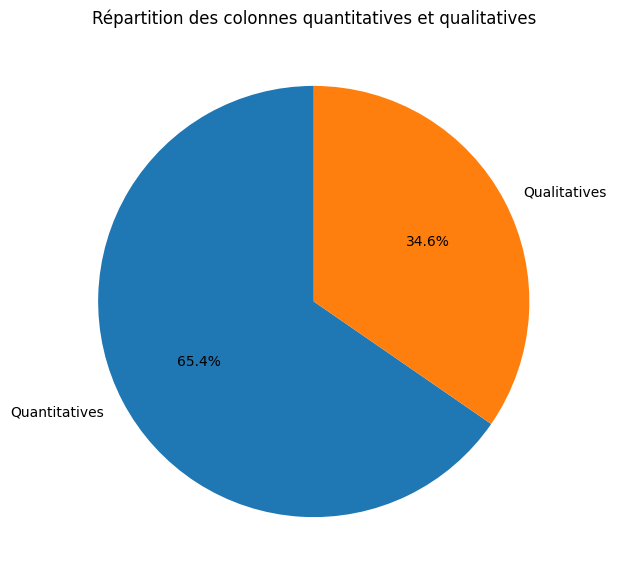

Quantitatives : 65.38%
Qualitatives : 34.62%


In [6]:
import matplotlib.pyplot as plt


n_quantitative = len(quantitative_cols)
n_qualitative = len(qualitative_cols)


sizes = [n_quantitative, n_qualitative]
labels = ["Quantitatives", "Qualitatives"]

# Création du graphique
plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des colonnes quantitatives et qualitatives")
plt.show()

total = n_quantitative + n_qualitative

pct_quantitative = (n_quantitative / total) * 100
pct_qualitative = (n_qualitative / total) * 100

print(f"Quantitatives : {pct_quantitative:.2f}%")
print(f"Qualitatives : {pct_qualitative:.2f}%")

In [7]:
quant_summary = df[quantitative_cols].describe().T

qual_summary = df[qualitative_cols].describe().T

print(" Résumé des colonnes quantitatives")
display(quant_summary)

print("Résumé des colonnes qualitatives ")
display(qual_summary)

 Résumé des colonnes quantitatives


,count,mean,std,min,25%,50%,75%,max
CustomerID,4372.0,15299.677722,1722.390705,12346.000000,13812.750000,15300.500000,16778.250000,18287.000000
Recency,4372.0,92.047118,100.765435,1.000000,17.000000,50.000000,143.000000,374.000000
Frequency,4372.0,5.075480,9.338754,1.000000,1.000000,3.000000,5.000000,248.000000
MonetaryTotal,4372.0,1898.459701,8219.345141,-4287.630000,293.362500,648.075000,1611.725000,279489.020000
MonetaryAvg,4372.0,28.839013,127.323926,-4287.630000,10.985960,16.918616,23.542941,3861.000000
MonetaryStd,4372.0,88.672383,2689.001161,0.000000,6.226414,10.349780,20.629858,137554.852393
MonetaryMin,4372.0,-86.425754,2876.398935,-168469.600000,-11.500000,0.790000,6.960000,3861.000000
MonetaryMax,4372.0,185.179522,2881.283699,-4287.630000,31.800000,52.020000,102.000000,168469.600000
TotalQuantity,4372.0,1122.344007,4672.790720,-303.000000,153.000000,365.000000,962.250000,196719.000000
AvgQuantityPerTransaction,4372.0,22.389288,213.257466,-144.000000,5.475745,9.494392,14.008333,12540.000000


Résumé des colonnes qualitatives 


,count,unique,top,freq
RegistrationDate,4372,1700,2010-12-21,11
NewsletterSubscribed,4372,1,Yes,4372
LastLoginIP,4372,4372,59.252.219.201,1
RFMSegment,4372,4,Potentiels,1589
AgeCategory,4372,7,Inconnu,1311
SpendingCategory,4372,4,High,1664
CustomerType,4372,5,Occasionnel,1198
FavoriteSeason,4372,4,Automne,1768
PreferredTimeOfDay,4372,4,Matin,1471
Region,4372,13,UK,3959


In [8]:
missing_cols = df.columns[df.isnull().sum() > 0]

missing_summary = pd.DataFrame({
    "Colonne": missing_cols,
    "Valeurs manquantes": [df[col].isnull().sum() for col in missing_cols],
    "Pourcentage des valeurs manquantes (%)": [round(df[col].isnull().mean() * 100, 2) for col in missing_cols]
})

display(missing_summary.sort_values(by="Pourcentage des valeurs manquantes (%)", ascending=False))

,Colonne,Valeurs manquantes,Pourcentage des valeurs manquantes (%)
1,Age,1311,29.99
0,AvgDaysBetweenPurchases,79,1.81


Colonne : Age
Nombre de valeurs non nulles : 3061
Moyenne : 49.15
Médiane : 49.00
Ecart-type : 18.27
Minimum : 18.00
Maximum : 80.00

Test de Shapiro-Wilk
Statistique = 0.9540
p-value = 0.000000
distribution non normale


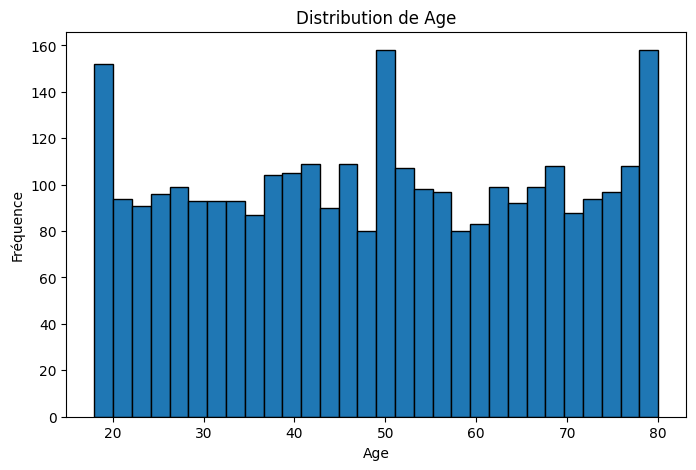

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

col = "Age"

s = df[col].dropna()

print(f"Colonne : {col}")
print(f"Nombre de valeurs non nulles : {s.shape[0]}")
print(f"Moyenne : {s.mean():.2f}")
print(f"Médiane : {s.median():.2f}")
print(f"Ecart-type : {s.std():.2f}")
print(f"Minimum : {s.min():.2f}")
print(f"Maximum : {s.max():.2f}")

# Test de normalité de Shapiro-Wilk
stat, p_value = stats.shapiro(s)

print(f"\nTest de Shapiro-Wilk")
print(f"Statistique = {stat:.4f}")
print(f"p-value = {p_value:.6f}")

if p_value > 0.05:
    print(" distribution normale ")
else:
    print("distribution non normale")

# Tracé de la distribution
plt.figure(figsize=(8,5))
plt.hist(s, bins=30, edgecolor="black")
plt.title(f"Distribution de {col}")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()

Colonne : AvgDaysBetweenPurchases
Nombre de valeurs non nulles : 4293
Moyenne : 3.40
Médiane : 1.15
Ecart-type : 11.49
Minimum : 0.00
Maximum : 309.00

Test de Shapiro-Wilk
Statistique = 0.2355
p-value = 0.000000
distribution non normale


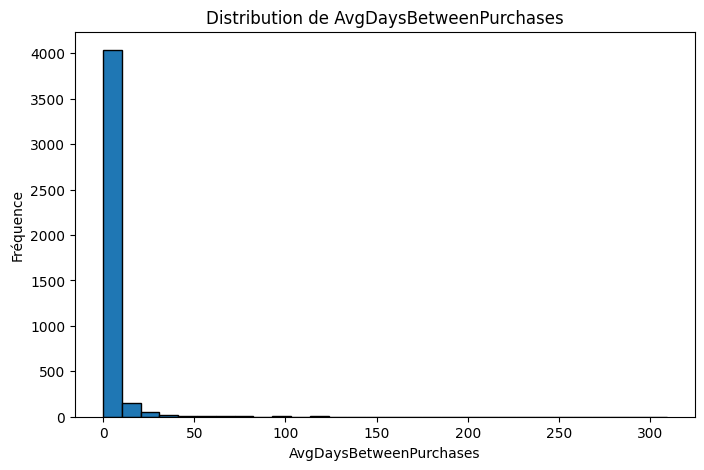

In [10]:

col = "AvgDaysBetweenPurchases"

s = df[col].dropna()

print(f"Colonne : {col}")
print(f"Nombre de valeurs non nulles : {s.shape[0]}")
print(f"Moyenne : {s.mean():.2f}")
print(f"Médiane : {s.median():.2f}")
print(f"Ecart-type : {s.std():.2f}")
print(f"Minimum : {s.min():.2f}")
print(f"Maximum : {s.max():.2f}")

stat, p_value = stats.shapiro(s)

print(f"\nTest de Shapiro-Wilk")
print(f"Statistique = {stat:.4f}")
print(f"p-value = {p_value:.6f}")

if p_value > 0.05:
    print("distribution normale")
else:
    print("distribution non normale")

plt.figure(figsize=(8,5))
plt.hist(s, bins=30, edgecolor="black")
plt.title(f"Distribution de {col}")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()

In [11]:
from scipy.stats import spearmanr, mannwhitneyu, kruskal
import pandas as pd
import numpy as np

def print_imputation_candidates(df, target):
    print(f" Candidats robustes pour imputer {target}")

    for col in df.columns:
        if col == target:
            continue

        temp = df[[target, col]].dropna()
        if len(temp) < 20:
            continue

        
        if pd.api.types.is_numeric_dtype(df[col]):
            rho, p_value = spearmanr(temp[target], temp[col])

            if (p_value < 0.01) and (abs(rho) >= 0.50):
                print(f"{col} -> Spearman | rho = {rho:.4f} | p = {p_value:.6f}")

       
        else:
            n_groups = temp[col].nunique()

           
            if n_groups == 2:
                groups = [g[target].values for _, g in temp.groupby(col)]

                if len(groups) == 2 and len(groups[0]) > 0 and len(groups[1]) > 0:
                    stat, p_value = mannwhitneyu(groups[0], groups[1], alternative="two-sided")

                    n1, n2 = len(groups[0]), len(groups[1])
                    r_rb = 1 - (2 * stat) / (n1 * n2)

                    if (p_value < 0.01) and (abs(r_rb) >= 0.30):
                        print(f"{col} -> Mann-Whitney | r_rb = {r_rb:.4f} | p = {p_value:.6f}")

           
            elif n_groups > 2:
                groups = [g[target].values for _, g in temp.groupby(col)]

                if all(len(g) > 0 for g in groups):
                    stat, p_value = kruskal(*groups)

                    n = len(temp)
                    k = len(groups)
                    epsilon_sq = (stat - k + 1) / (n - k) if n > k else np.nan

                    if (p_value < 0.01) and (epsilon_sq >= 0.14):
                        print(f"{col} -> Kruskal-Wallis | epsilon² = {epsilon_sq:.4f} | p = {p_value:.6f}")

In [12]:
print_imputation_candidates(df, "Age")

 Candidats robustes pour imputer Age
AgeCategory -> Kruskal-Wallis | epsilon² = 0.9657 | p = 0.000000


In [13]:
print_imputation_candidates(df, "AvgDaysBetweenPurchases")

 Candidats robustes pour imputer AvgDaysBetweenPurchases
Frequency -> Spearman | rho = 0.5959 | p = 0.000000
CustomerTenureDays -> Spearman | rho = 0.7583 | p = 0.000000
UniqueInvoices -> Spearman | rho = 0.5959 | p = 0.000000
RFMSegment -> Kruskal-Wallis | epsilon² = 0.1834 | p = 0.000000
SpendingCategory -> Kruskal-Wallis | epsilon² = 0.1632 | p = 0.000000
CustomerType -> Kruskal-Wallis | epsilon² = 0.3240 | p = 0.000000
LoyaltyLevel -> Kruskal-Wallis | epsilon² = 0.6726 | p = 0.000000


In [14]:
text_markers = ["", "inconnu", "unknown", "na", "n/a", "none", "null", "missing", "?"]
numeric_markers_global = [-999, -9999]

valid_intervals = {
    "SupportTicketsCount": (0, 15),
    "SatisfactionScore": (1, 5)
}

results = []

for col in df.columns:
    s = df[col]

    # Colonnes texte
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s_norm = s.astype(str).str.strip().str.lower()
        for marker in text_markers:
            n = (s_norm == marker).sum()
            if n > 0:
                results.append({
                    "Colonne": col,
                    "Valeur suspecte": repr(marker),
                    "Type": "Texte",
                    "Critère": "Marqueur texte suspect",
                    "Occurrences": n,
                    "Pourcentage (%)": round(n / len(df) * 100, 2)
                })

    # Colonnes numériques
    elif pd.api.types.is_numeric_dtype(s):
        # Marqueurs globaux
        for marker in numeric_markers_global:
            n = (s == marker).sum()
            if n > 0:
                results.append({
                    "Colonne": col,
                    "Valeur suspecte": marker,
                    "Type": "Numérique",
                    "Critère": "Marqueur numérique suspect",
                    "Occurrences": n,
                    "Pourcentage (%)": round(n / len(df) * 100, 2)
                })

        # Vérification par intervalle valide pour certaines colonnes
        if col in valid_intervals:
            low, high = valid_intervals[col]
            invalid_values = s[(s < low) | (s > high)]

            if not invalid_values.empty:
                for value, count in invalid_values.value_counts().items():
                    results.append({
                        "Colonne": col,
                        "Valeur suspecte": value,
                        "Type": "Numérique",
                        "Critère": f"Hors intervalle [{low}, {high}]",
                        "Occurrences": count,
                        "Pourcentage (%)": round(count / len(df) * 100, 2)
                    })

sentinel_summary = pd.DataFrame(results)
display(sentinel_summary.sort_values(["Colonne", "Occurrences"], ascending=[True, False]))

,Colonne,Valeur suspecte,Type,Critère,Occurrences,Pourcentage (%)
5,AgeCategory,'inconnu',Texte,Marqueur texte suspect,1311,29.99
7,Gender,'unknown',Texte,Marqueur texte suspect,1649,37.72
2,SatisfactionScore,0.0,Numérique,"Hors intervalle [1, 5]",120,2.74
3,SatisfactionScore,-1.0,Numérique,"Hors intervalle [1, 5]",115,2.63
4,SatisfactionScore,99.0,Numérique,"Hors intervalle [1, 5]",114,2.61
0,SupportTicketsCount,999.0,Numérique,"Hors intervalle [0, 15]",87,1.99
1,SupportTicketsCount,-1.0,Numérique,"Hors intervalle [0, 15]",43,0.98
6,WeekendPreference,'inconnu',Texte,Marqueur texte suspect,3125,71.48


In [15]:
def rank_biserial_values_suspect(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

def print_candidates_for_target(df, target, low, high):
    print(f" Candidats pour imputer {target} ")
    print(f"Valeurs valides utilisées pour le test : [{low}, {high}]")

    # on garde seulement les lignes où la cible est dans l'intervalle valide
    df_valid = df[df[target].between(low, high, inclusive="both")].copy()

    
    print(" Candidats quantitatifs (Spearman) ")
    found_num = False

    num_cols = df_valid.select_dtypes(include=["int64", "float64"]).columns.tolist()
    num_cols = [col for col in num_cols if col != target]

    for col in num_cols:
        temp = df_valid[[target, col]].dropna()
        if temp.empty:
            continue

        rho, p_value = spearmanr(temp[target], temp[col])

        if p_value < 0.01 and abs(rho) >= 0.50:
            found_num = True
            print(f"{col} -> rho = {rho:.4f} | p = {p_value:.6f}")

    if not found_num:
        print("Aucun candidat quantitatif robuste trouvé.")

 
    print(" Candidats qualitatifs")
    found_cat = False

    cat_cols = df_valid.select_dtypes(include=["object", "string"]).columns.tolist()

    for col in cat_cols:
        temp = df_valid[[target, col]].dropna()
        if temp.empty:
            continue

        n_groups = temp[col].nunique()

        # binaire
        if n_groups == 2:
            groups = [g[target].values for _, g in temp.groupby(col)]
            if len(groups[0]) == 0 or len(groups[1]) == 0:
                continue

            stat, p_value = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            r_rb = rank_biserial_values_suspect(stat, len(groups[0]), len(groups[1]))

            if p_value < 0.01 and abs(r_rb) >= 0.30:
                found_cat = True
                print(f"{col} -> Mann-Whitney | r_rb = {r_rb:.4f} | p = {p_value:.6f}")

        # plus de 2 modalités
        elif n_groups > 2:
            groups = [g[target].values for _, g in temp.groupby(col)]
            if not all(len(g) > 0 for g in groups):
                continue

            stat, p_value = kruskal(*groups)
            n = len(temp)
            k = len(groups)
            epsilon_sq = (stat - k + 1) / (n - k) if n > k else np.nan

            if p_value < 0.01 and epsilon_sq >= 0.14:
                found_cat = True
                print(f"{col} -> Kruskal-Wallis | epsilon² = {epsilon_sq:.4f} | p = {p_value:.6f}")

    if not found_cat:
        print("Aucun candidat qualitatif robuste trouvé.")

In [16]:
print_candidates_for_target(df, "SupportTicketsCount", 0, 15)

 Candidats pour imputer SupportTicketsCount 
Valeurs valides utilisées pour le test : [0, 15]
 Candidats quantitatifs (Spearman) 
Aucun candidat quantitatif robuste trouvé.
 Candidats qualitatifs
Aucun candidat qualitatif robuste trouvé.


In [17]:
print_candidates_for_target(df, "SatisfactionScore", 1, 5)

 Candidats pour imputer SatisfactionScore 
Valeurs valides utilisées pour le test : [1, 5]
 Candidats quantitatifs (Spearman) 
Aucun candidat quantitatif robuste trouvé.
 Candidats qualitatifs
Aucun candidat qualitatif robuste trouvé.


In [18]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np

target = "Gender"

def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)


df_gender = df[df[target].isin(["M", "F"])]


qual_scores = []

qual_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
qual_cols = [col for col in qual_cols if col != target]

for col in qual_cols:
    temp = df_gender[[target, col]].dropna()

    if temp.empty or temp[col].nunique() < 2:
        continue

    table = pd.crosstab(temp[target], temp[col])

    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(table)
    v = cramers_v(table)

    if p_value < 0.05:
        qual_scores.append((col, v, p_value))

qual_scores = sorted(qual_scores, key=lambda x: x[1], reverse=True)

print(" Meilleurs candidats qualitatifs pour Gender")
for col, v, p in qual_scores[:5]:
    print(f"{col} -> Cramér's V = {v:.4f} | p-value = {p:.6f}")

 Meilleurs candidats qualitatifs pour Gender
AccountStatus -> Cramér's V = 0.0649 | p-value = 0.009488


In [48]:

num_scores = []

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in num_cols:
    temp = df_gender[[target, col]].dropna()

    g_m = temp[temp[target] == "M"][col]
    g_f = temp[temp[target] == "F"][col]

    if len(g_m) == 0 or len(g_f) == 0:
        continue

    u_stat, p_value = mannwhitneyu(g_m, g_f, alternative="two-sided")
    r_rb = rank_biserial(u_stat, len(g_m), len(g_f))

    if p_value < 0.05:
        num_scores.append((col, abs(r_rb), r_rb, p_value))

num_scores = sorted(num_scores, key=lambda x: x[1], reverse=True)

print(" Meilleurs candidats quantitatifs pour Gender ")
for col, abs_r, r_rb, p in num_scores[:5]:
    print(f"{col} -> Rank-biserial = {r_rb:.4f} | p-value = {p:.6f}")

 Meilleurs candidats quantitatifs pour Gender 


In [19]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = round((duplicate_count / len(df)) * 100, 2)

print("Nombre de doublons :", duplicate_count)
print("Pourcentage de doublons (%) :", duplicate_percentage)

Nombre de doublons : 0
Pourcentage de doublons (%) : 0.0


In [20]:
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]

print("Colonnes constantes :")
print(constant_cols)

print("\nNombre de colonnes constantes :", len(constant_cols))

Colonnes constantes :
['NewsletterSubscribed']

Nombre de colonnes constantes : 1


In [21]:
for col in constant_cols:
    print(f"{col} -> valeur constante : {df[col].iloc[0]}")

NewsletterSubscribed -> valeur constante : Yes


In [22]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

categorical_value_distributions = {}

for col in categorical_cols:
    s = df[col].astype("object").where(df[col].notna(), "NaN")
    
    freq_table = s.value_counts(dropna=False).reset_index()
    freq_table.columns = ["Valeur", "Occurrences"]
    freq_table["Pourcentage (%)"] = (freq_table["Occurrences"] / len(df) * 100).round(2)
    
    categorical_value_distributions[col] = freq_table

for col, table in categorical_value_distributions.items():
    print(f" {col}")
    display(table)

 RegistrationDate


,Valeur,Occurrences,Pourcentage (%)
0,2010-12-21,11,0.25
1,12/10/2010,11,0.25
2,2010-12-22,10,0.23
3,01/01/2011,10,0.23
4,01/28/2011,10,0.23
...,...,...,...
1695,11/02/2011,1,0.02
1696,11/22/2011,1,0.02
1697,12/30/2011,1,0.02
1698,2011-12-06,1,0.02


 NewsletterSubscribed


,Valeur,Occurrences,Pourcentage (%)
0,Yes,4372,100.0


 LastLoginIP


...

,Valeur,Occurrences,Pourcentage (%)
0,Unknown,1649,37.72
1,F,1389,31.77
2,M,1334,30.51


 AccountStatus


,Valeur,Occurrences,Pourcentage (%)
0,Active,3944,90.21
1,Suspended,213,4.87
2,Pending,131,3.00
3,Closed,84,1.92


 Country


,Valeur,Occurrences,Pourcentage (%)
0,United Kingdom,3950,90.35
1,Germany,95,2.17
2,France,87,1.99
3,Spain,30,0.69
4,Belgium,24,0.55
5,Switzerland,20,0.46
6,Portugal,19,0.43
7,Italy,15,0.34
8,Finland,12,0.27
9,Norway,10,0.23


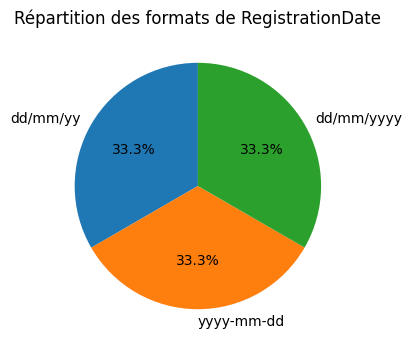

In [23]:
import re


col = "RegistrationDate"

def detect_date_format(x):
    x = str(x).strip()
    
    if re.fullmatch(r"\d{2}/\d{2}/\d{2}", x):
        return "dd/mm/yy"
    elif re.fullmatch(r"\d{2}/\d{2}/\d{4}", x):
        return "dd/mm/yyyy"
    elif re.fullmatch(r"\d{4}-\d{2}-\d{2}", x):
        return "yyyy-mm-dd"
    else:
        return "Format non reconnu"

format_counts = df[col].apply(detect_date_format).value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    format_counts,
    labels=format_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Répartition des formats de RegistrationDate")
plt.show()

Nombre de formats différents détectés : 1
LastLoginIP
IPv4    4372
Name: count, dtype: int64


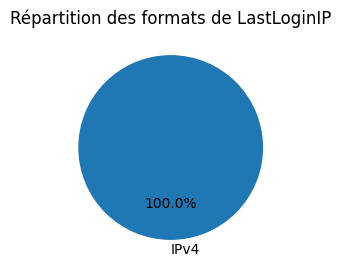

In [24]:
import re
import matplotlib.pyplot as plt

col = "LastLoginIP"

def detect_ip_format(x):
    x = str(x).strip()
    
    # IPv4
    if re.fullmatch(r"(\d{1,3}\.){3}\d{1,3}", x):
        return "IPv4"
    
    # IPv6
    elif re.fullmatch(r"([0-9a-fA-F]{1,4}:){1,7}[0-9a-fA-F]{1,4}", x):
        return "IPv6"
    
    else:
        return "Format non reconnu"

ip_format_counts = df[col].apply(detect_ip_format).value_counts()

print("Nombre de formats différents détectés :", ip_format_counts.shape[0])
print(ip_format_counts)

plt.figure(figsize=(3, 3))
plt.pie(
    ip_format_counts,
    labels=ip_format_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Répartition des formats de LastLoginIP")
plt.show()

In [25]:
quant_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

outlier_summary = []

for col in quant_cols:
    s = df[col].dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((s < lower) | (s > upper)).sum()
    pct_outliers = round((n_outliers / len(s)) * 100, 2)

    outlier_summary.append({
        "Colonne": col,
        "Nombre d'outliers": n_outliers,
        "Pourcentage d'outliers (%)": pct_outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary = outlier_summary[outlier_summary["Nombre d'outliers"] > 0]
outlier_summary = outlier_summary.sort_values(by="Pourcentage d'outliers (%)", ascending=False)

display(outlier_summary)

,Colonne,Nombre d'outliers,Pourcentage d'outliers (%)
17,WeekendPurchaseRatio,833,19.05
23,NegativeQuantityCount,783,17.91
25,CancelledTransactions,783,17.91
10,MinQuantity,771,17.63
26,ReturnRatio,623,14.25
6,MonetaryMin,519,11.87
4,MonetaryAvg,505,11.55
7,MonetaryMax,501,11.46
5,MonetaryStd,482,11.02
3,MonetaryTotal,423,9.68


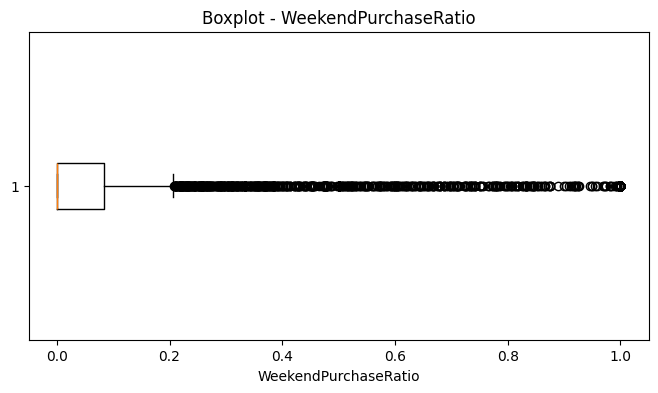

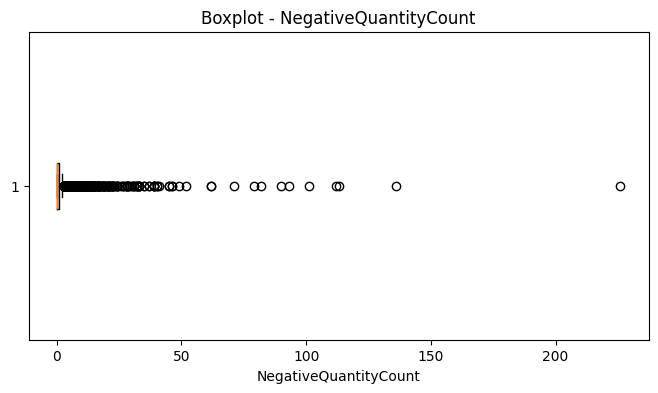

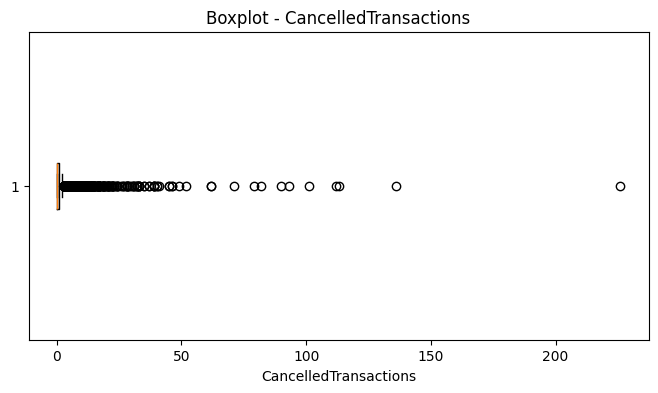

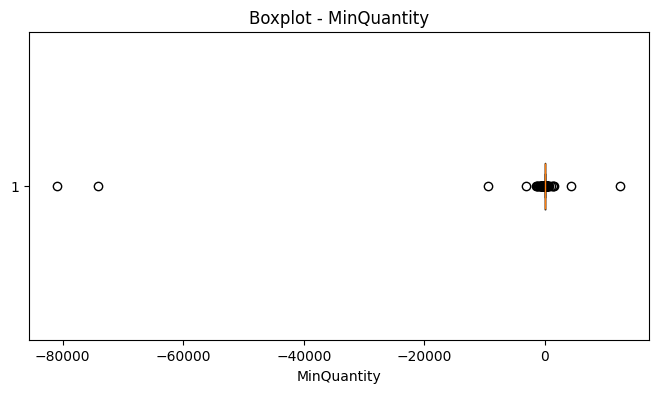

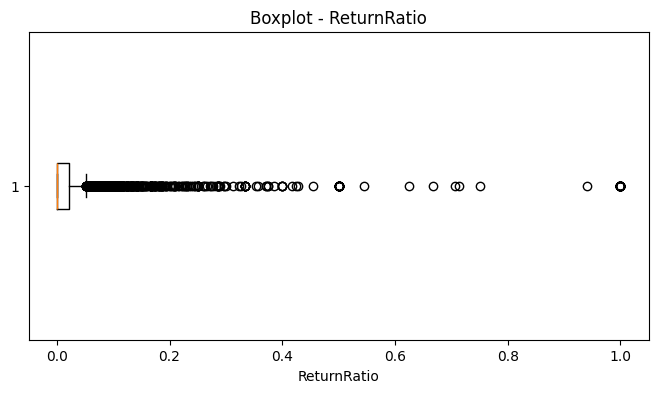

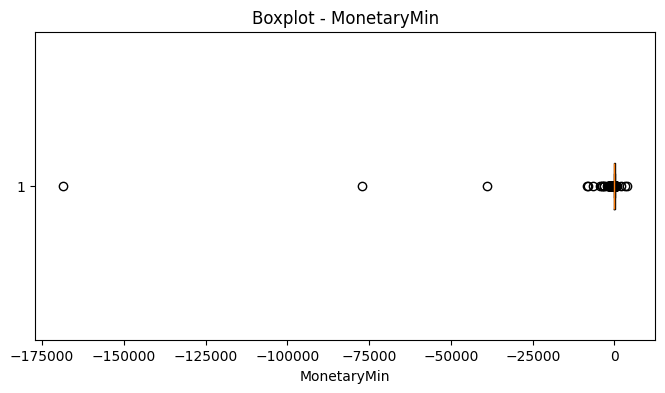

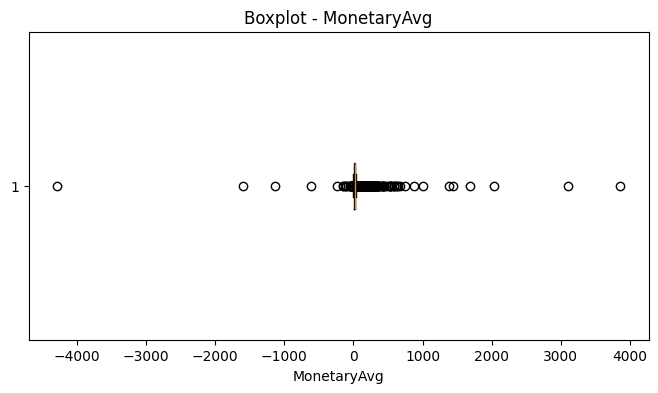

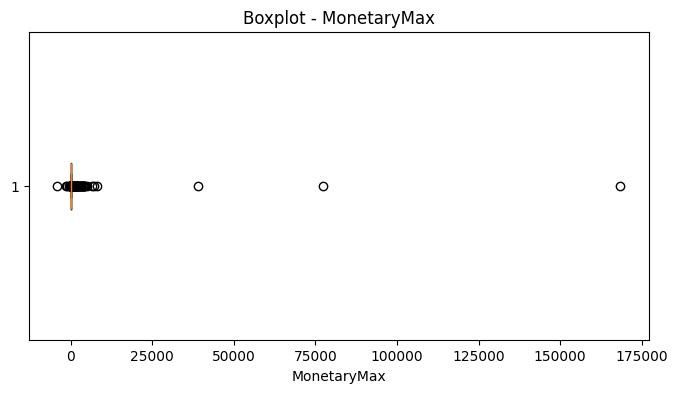

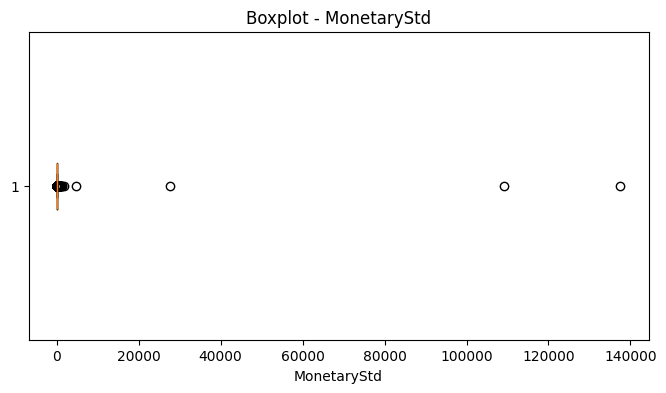

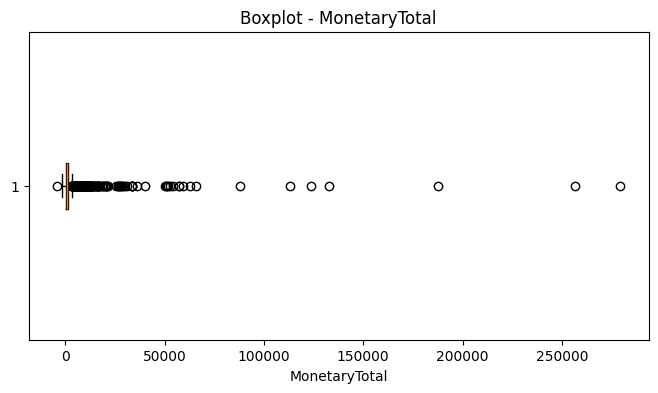

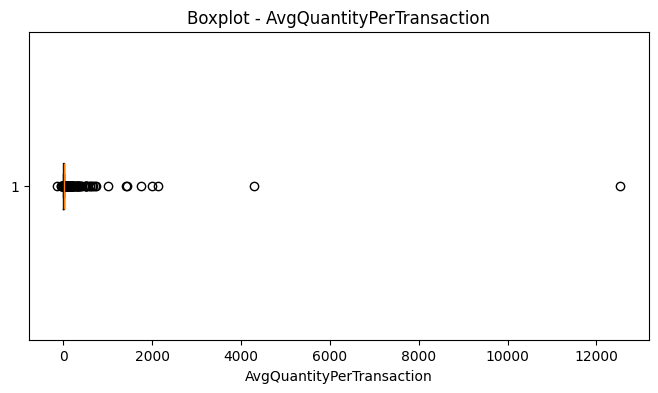

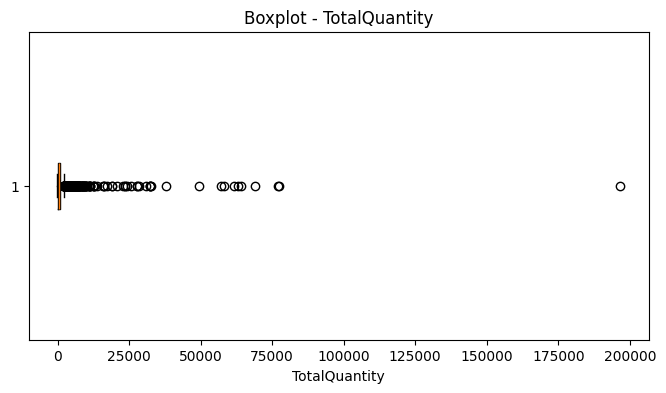

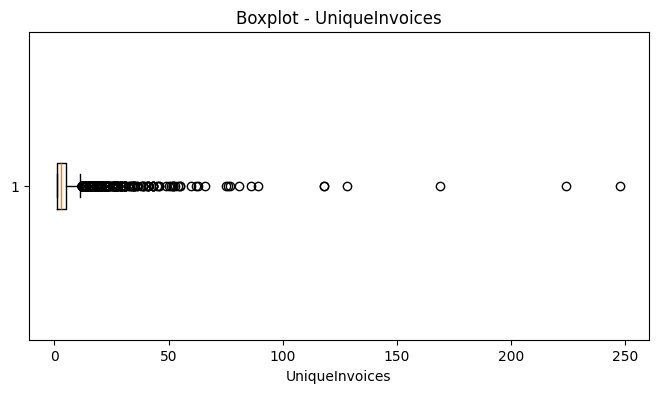

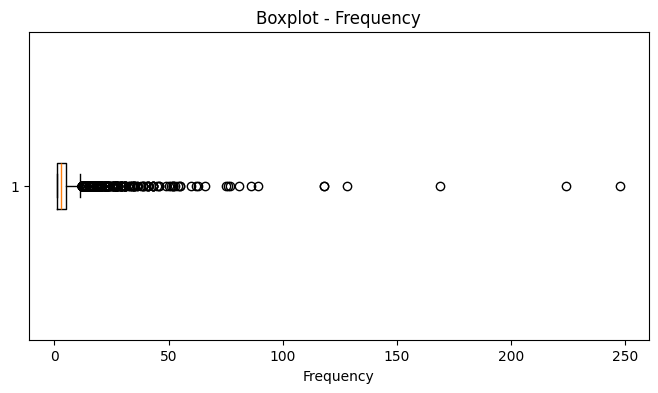

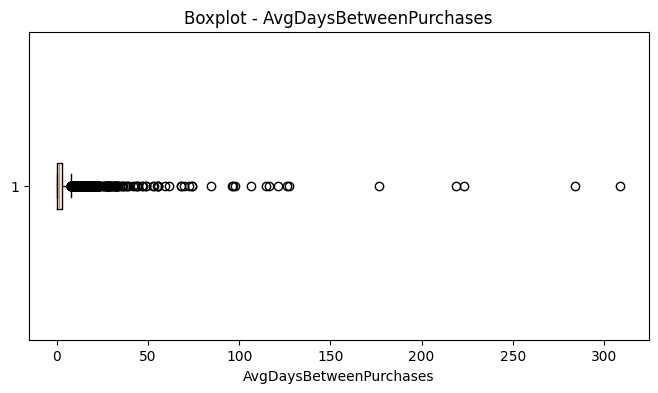

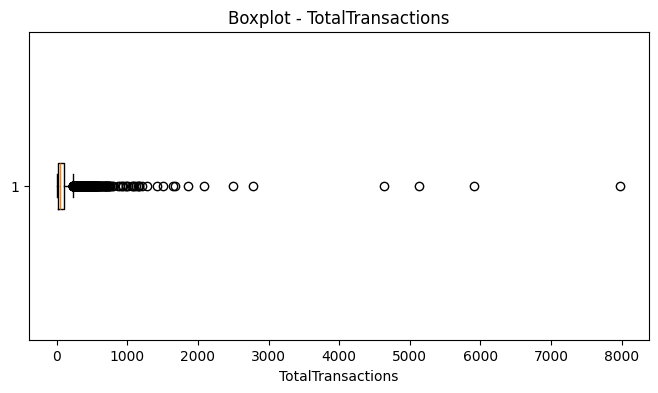

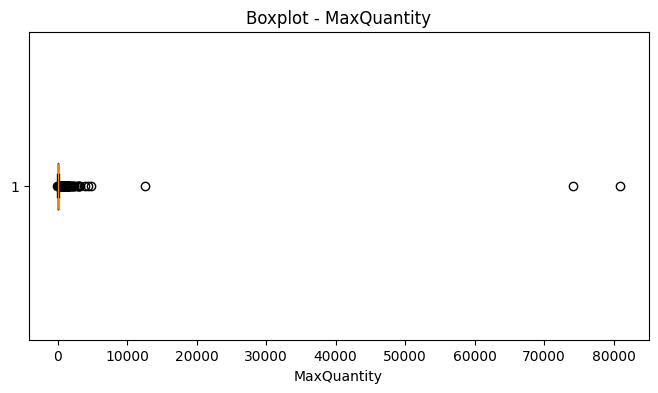

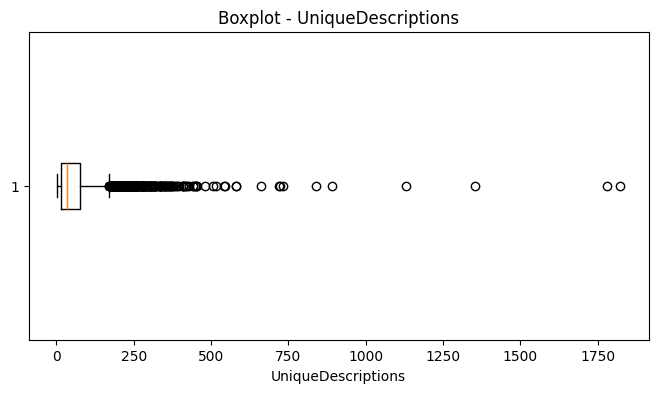

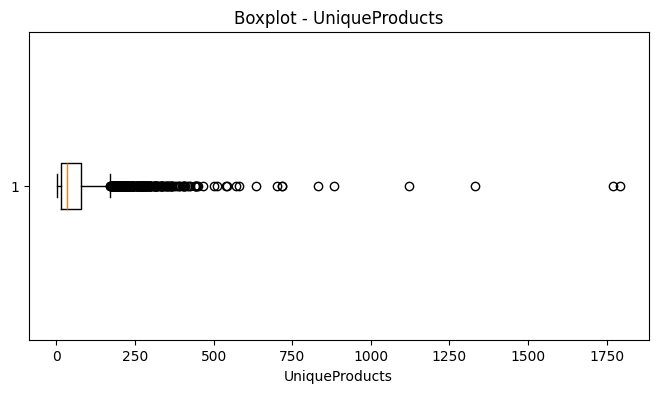

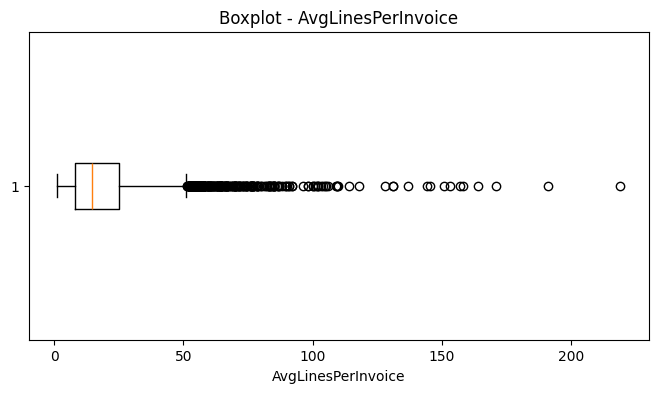

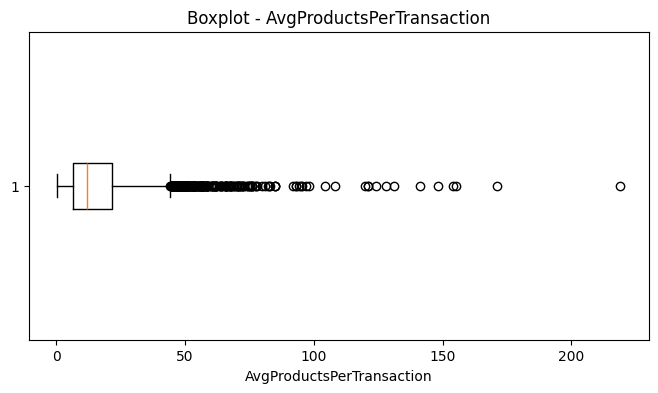

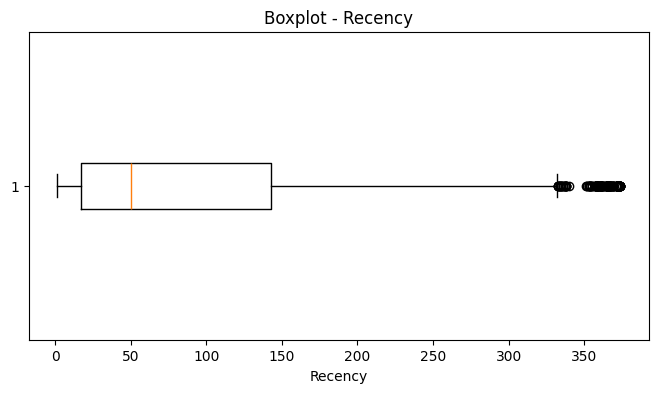

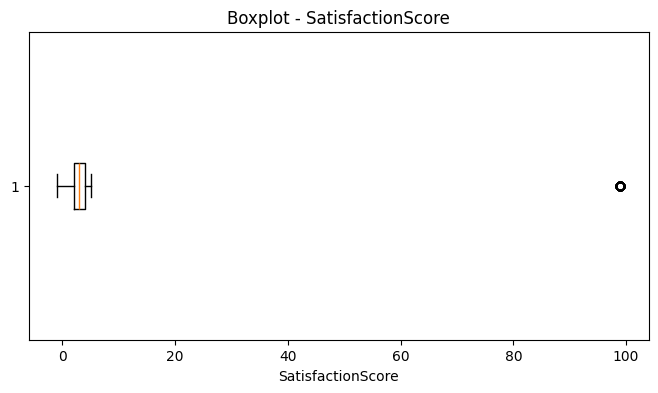

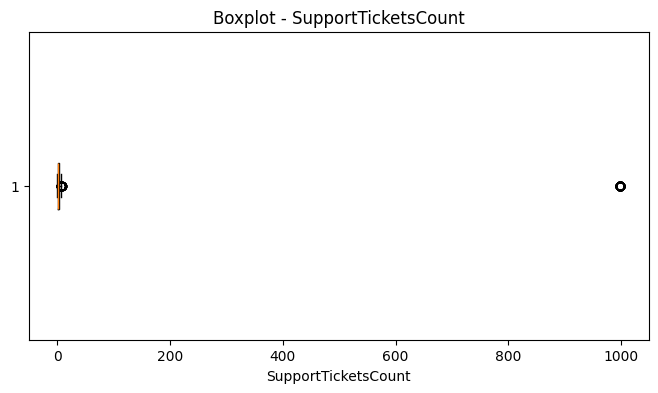

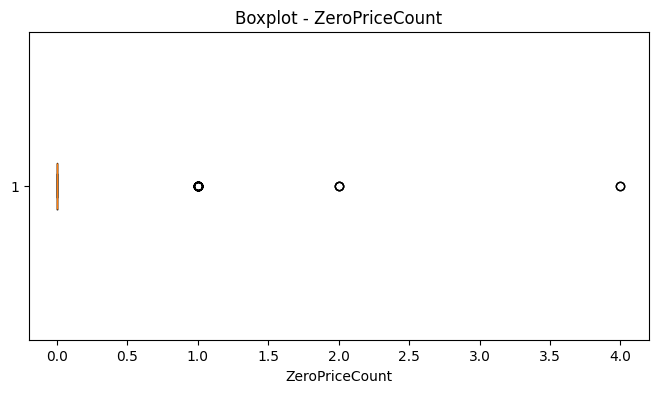

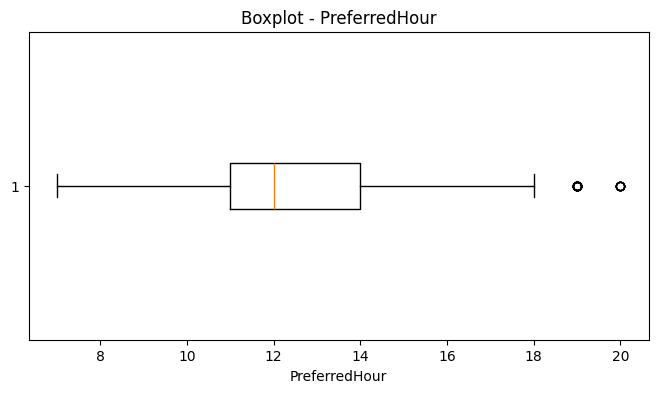

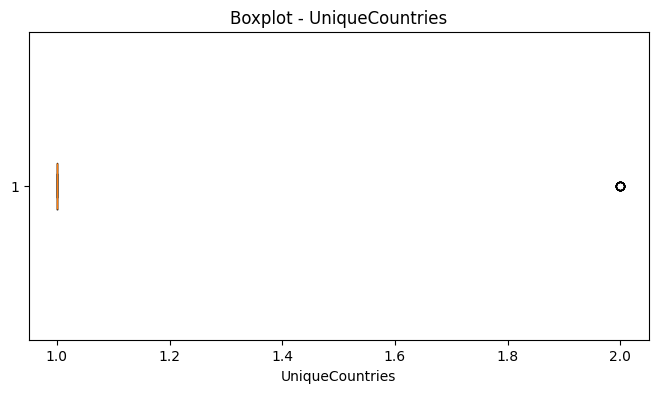

In [26]:


cols_with_outliers = outlier_summary["Colonne"].tolist()

for col in cols_with_outliers:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

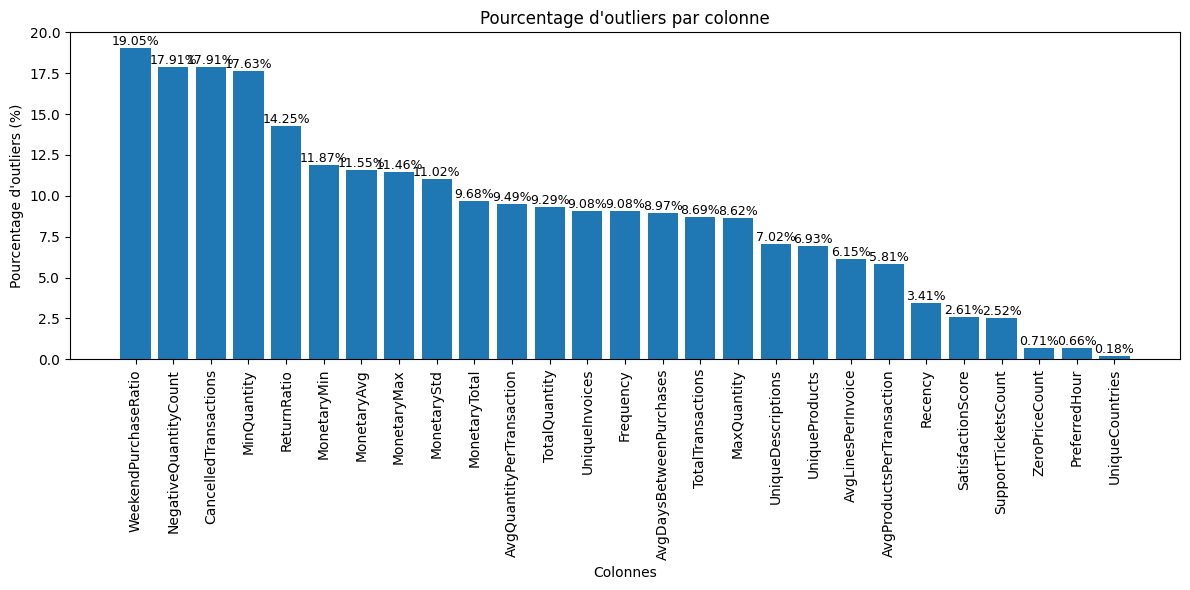

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bars = plt.bar(outlier_summary["Colonne"], outlier_summary["Pourcentage d'outliers (%)"])

plt.xticks(rotation=90)
plt.xlabel("Colonnes")
plt.ylabel("Pourcentage d'outliers (%)")
plt.title("Pourcentage d'outliers par colonne")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [28]:
target = "Churn"

class_counts = df[target].value_counts().sort_index()
class_percentages = round(df[target].value_counts(normalize=True).sort_index() * 100, 2)

print("Nombre par classe :")
print(class_counts)

print("\nPourcentage par classe (%) :")
print(class_percentages)

Nombre par classe :
Churn
0    2918
1    1454
Name: count, dtype: int64

Pourcentage par classe (%) :
Churn
0    66.74
1    33.26
Name: proportion, dtype: float64


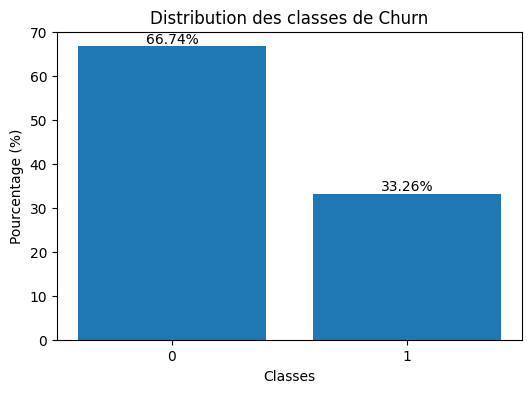

In [66]:

plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index.astype(str), class_percentages.values)

plt.xlabel("Classes")
plt.ylabel("Pourcentage (%)")
plt.title(f"Distribution des classes de {target}")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [29]:
import math
import matplotlib.pyplot as plt


quant_cols = [
    'CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
    'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity',
    'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity',
    'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek',
    'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio',
    'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions',
    'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount',
    'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio',
    'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age',
    'SupportTicketsCount', 'SatisfactionScore'
]

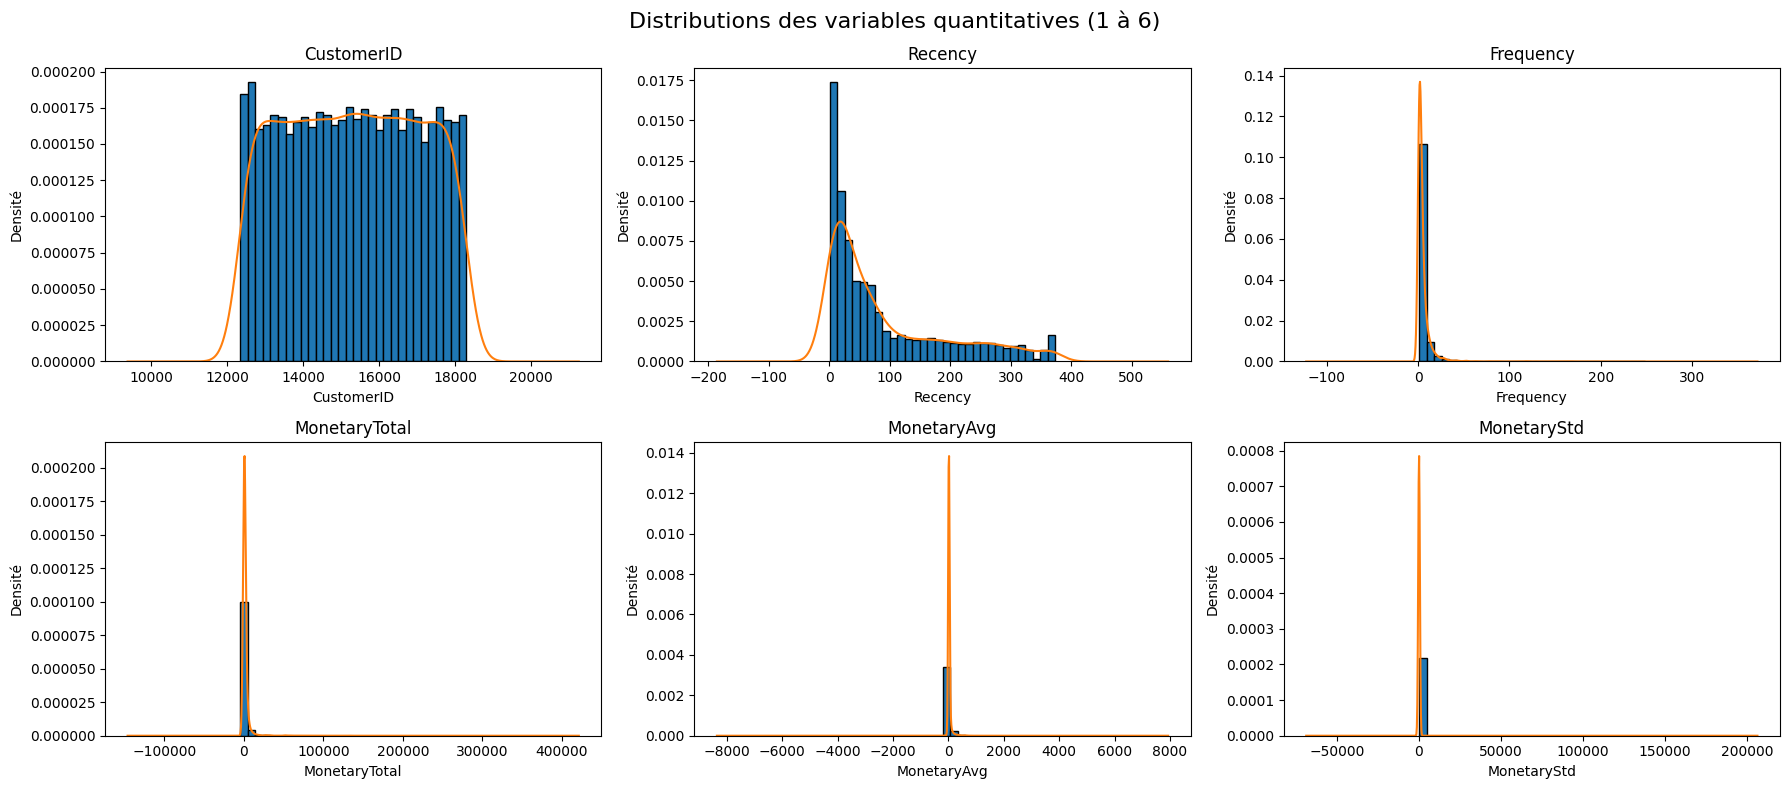

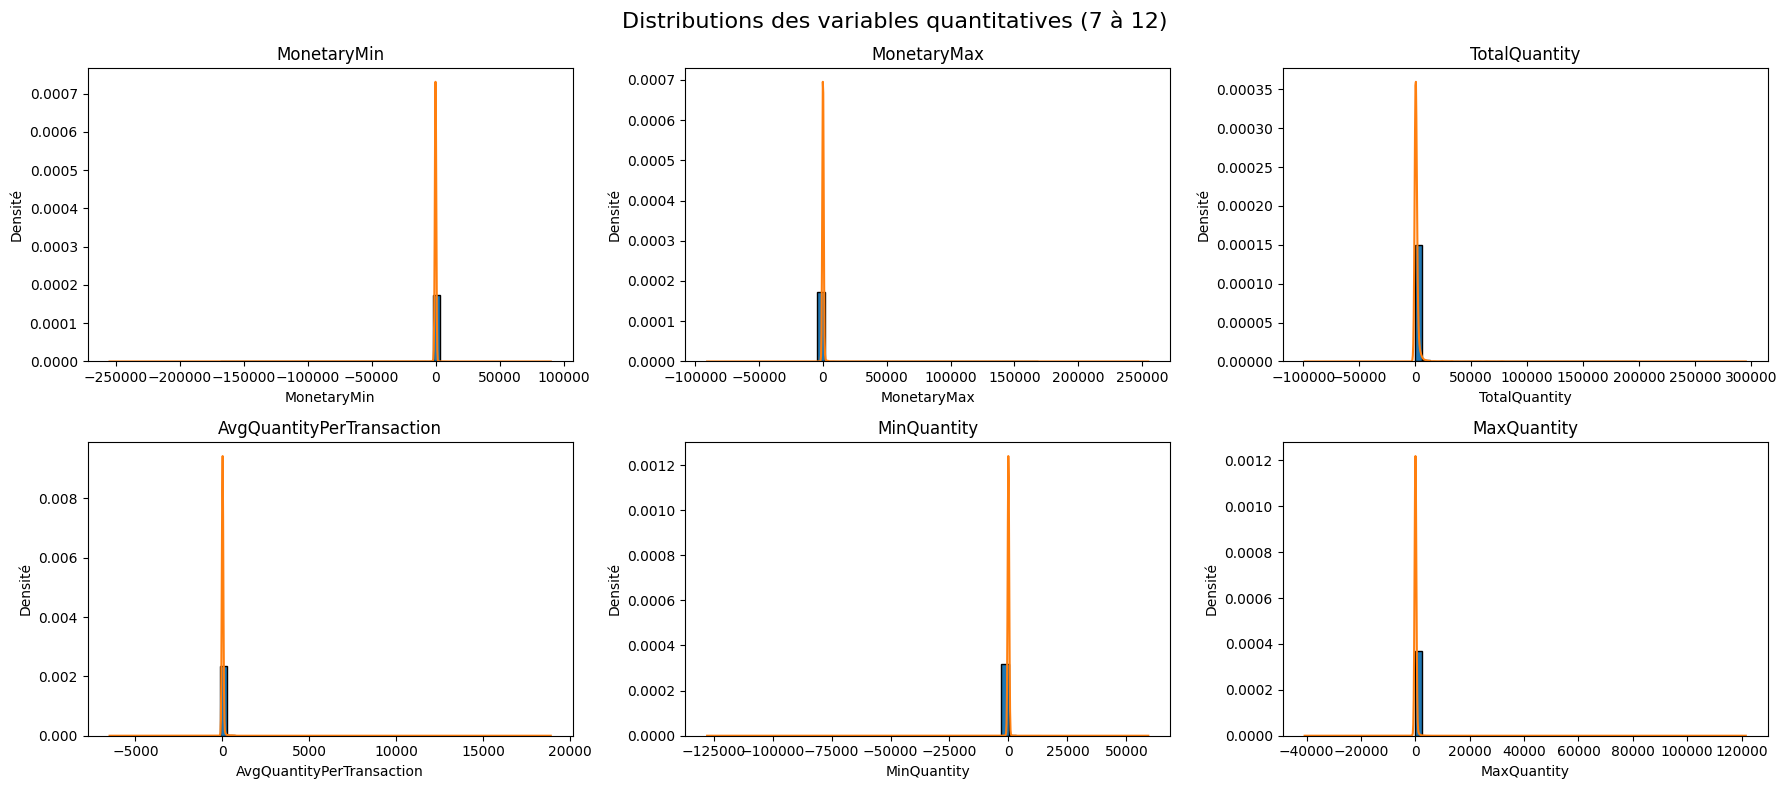

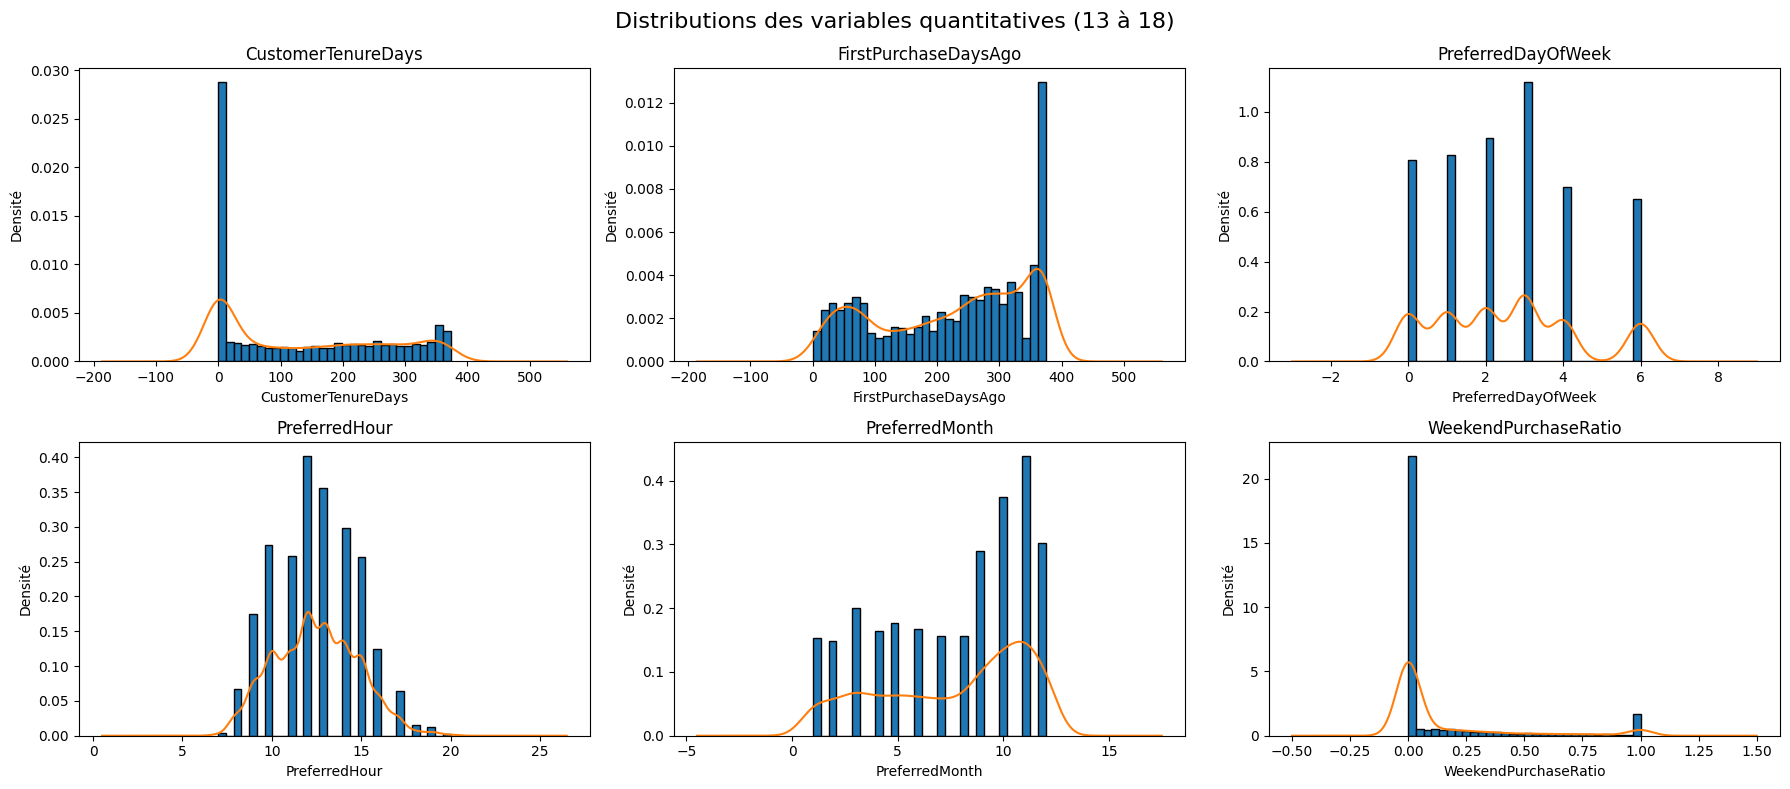

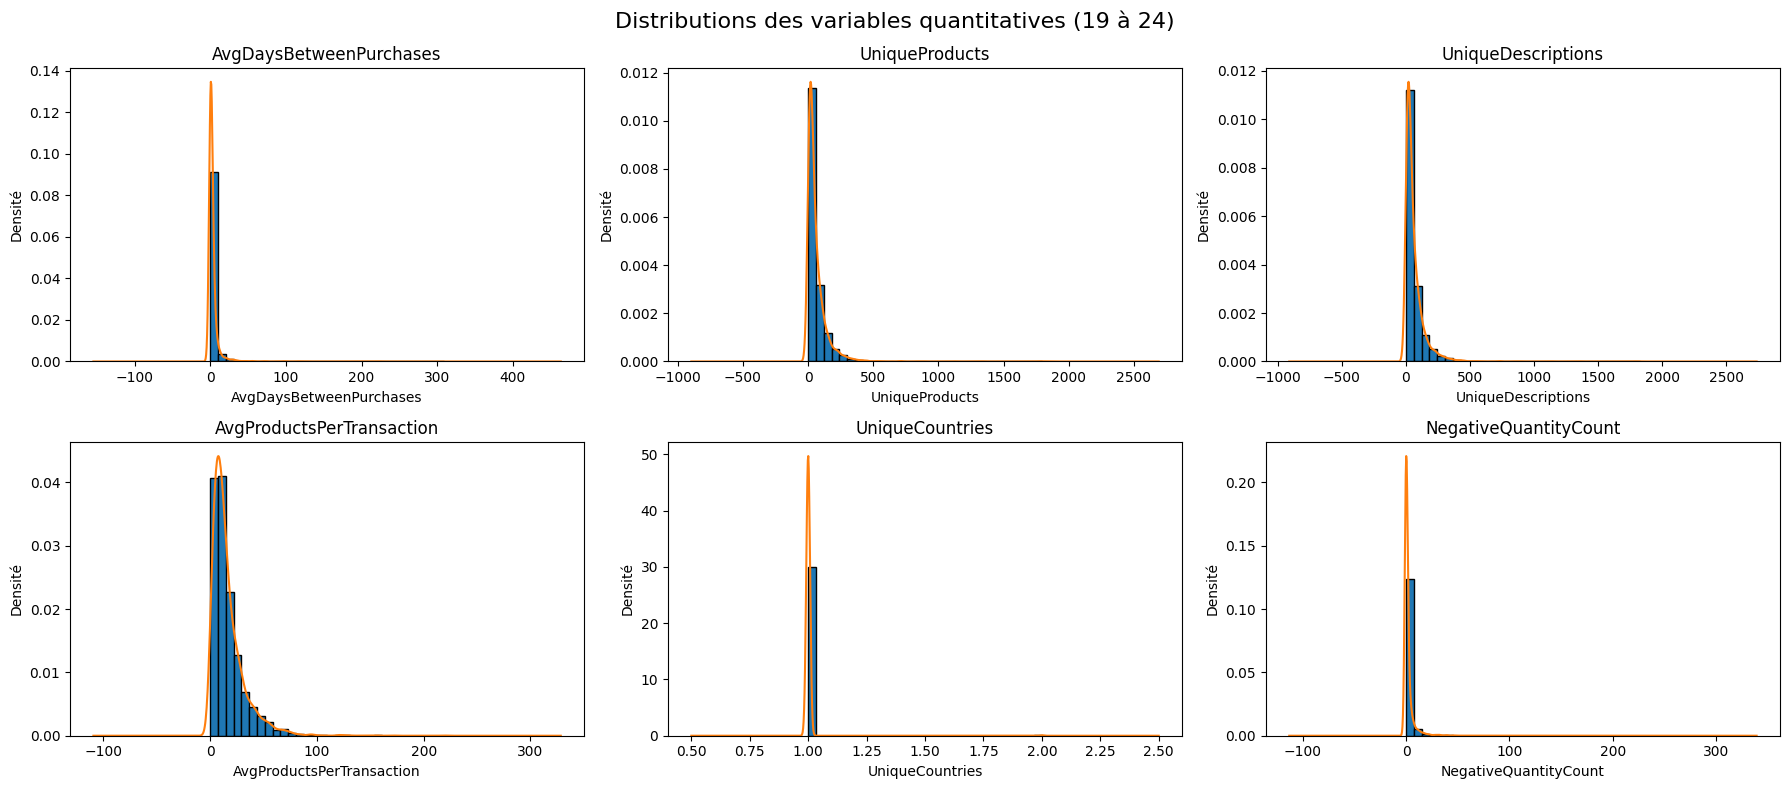

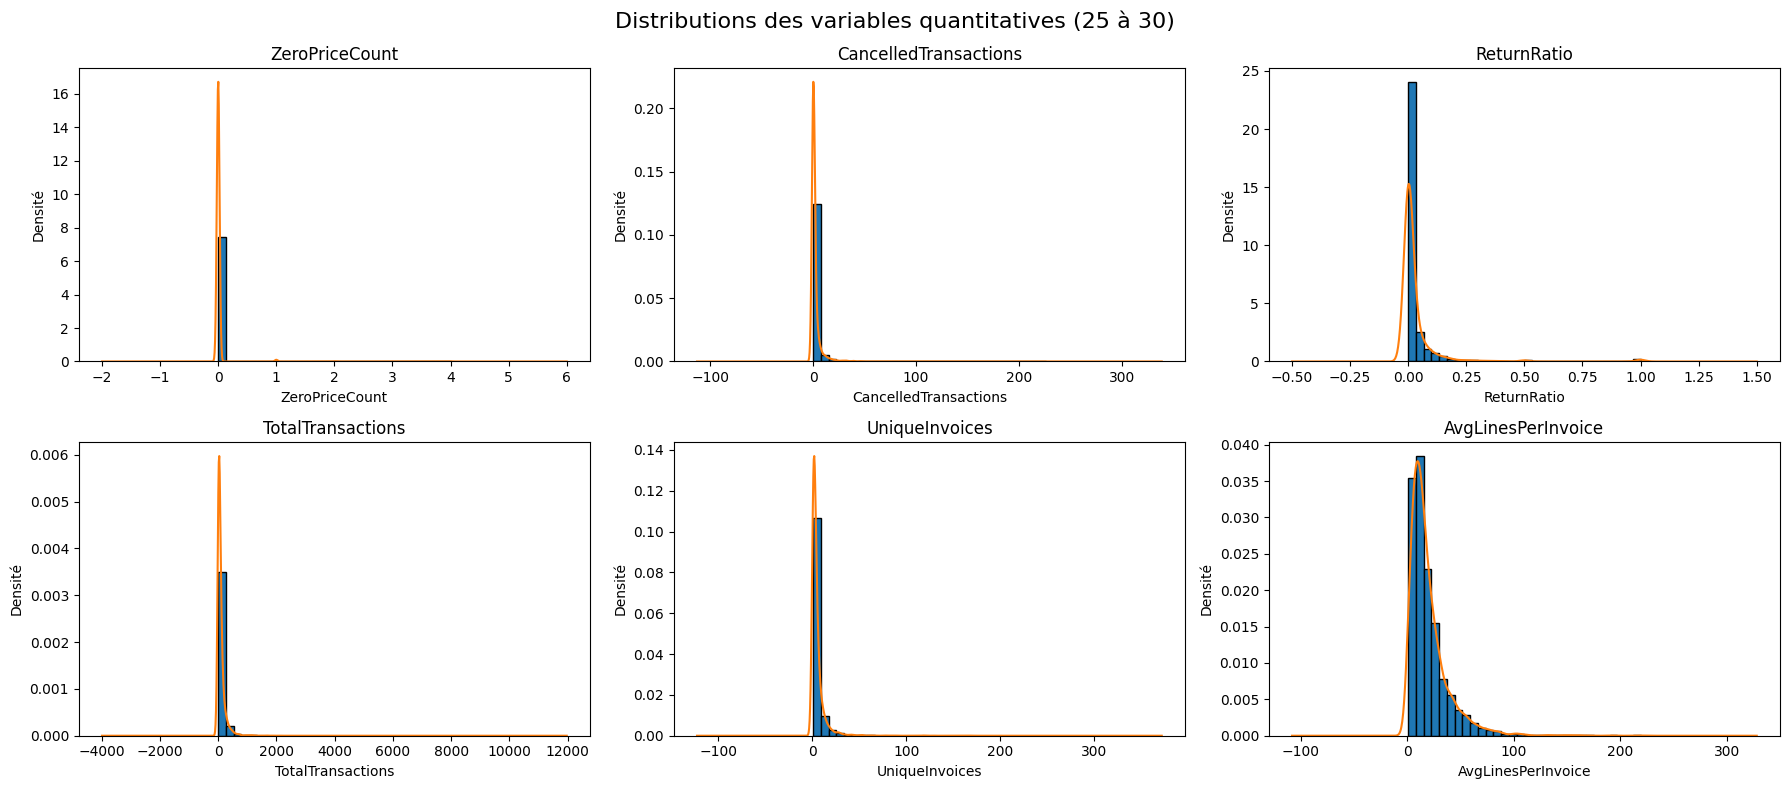

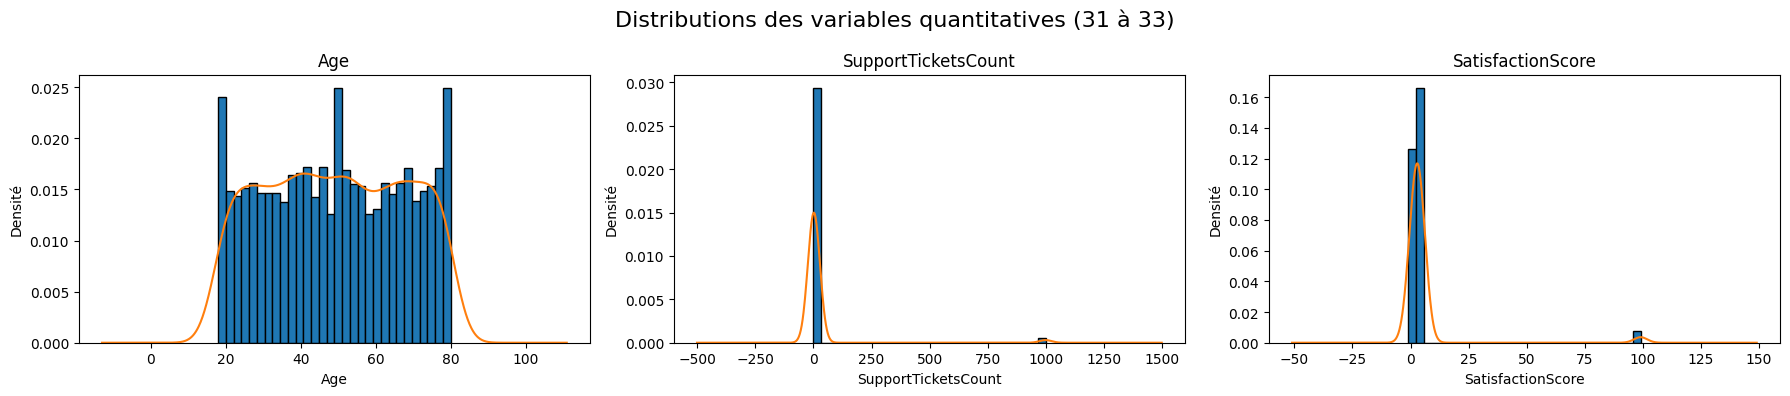

In [30]:
group_size = 6   # nombre de variables par figure
n_cols = 3       # nombre de colonnes de subplots

for i in range(0, len(quant_cols), group_size):
    cols_group = quant_cols[i:i + group_size]
    n_plots = len(cols_group)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, cols_group):
        s = df[col].dropna()

        ax.hist(s, bins=30, density=True, edgecolor="black")
        
        if s.nunique() > 1:
            s.plot(kind="kde", ax=ax)

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Densité")

    # masquer les axes inutilisés
    for j in range(len(cols_group), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Distributions des variables quantitatives ({i+1} à {i+len(cols_group)})", fontsize=16)
    plt.tight_layout()
    plt.show()

In [31]:
results = []

for col in quant_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    
    if len(s) == 0:
        continue

    mean_val = s.mean()
    median_val = s.median()
    mode_val = s.mode().iloc[0] if not s.mode().empty else np.nan
    skew_val = s.skew()

    # Décision principale avec skewness
    if abs(skew_val) < 0.5:
        shape = "Approx. symétrique"
    elif skew_val > 0:
        shape = "Asymétrique positive (à droite)"
    else:
        shape = "Asymétrique négative (à gauche)"

    results.append({
        "Variable": col,
        "Mean": round(mean_val, 3),
        "Median": round(median_val, 3),
        "Mode": round(mode_val, 3) if pd.notna(mode_val) else np.nan,
        "Skewness": round(skew_val, 3),
        "Distribution": shape
    })

symmetry_df = pd.DataFrame(results)
display(symmetry_df.sort_values("Skewness"))

,Variable,Mean,Median,Mode,Skewness,Distribution
6,MonetaryMin,-86.426,0.790,5.04,-50.904,Asymétrique négative (à gauche)
10,MinQuantity,-37.791,1.000,1.00,-45.131,Asymétrique négative (à gauche)
16,PreferredMonth,7.605,9.000,11.00,-0.458,Approx. symétrique
13,FirstPurchaseDaysAgo,225.779,253.000,372.00,-0.389,Approx. symétrique
0,CustomerID,15299.678,15300.500,12346.00,0.001,Approx. symétrique
30,Age,49.150,49.000,77.00,0.004,Approx. symétrique
15,PreferredHour,12.487,12.000,12.00,0.154,Approx. symétrique
14,PreferredDayOfWeek,2.536,2.000,3.00,0.418,Approx. symétrique
12,CustomerTenureDays,133.386,97.500,0.00,0.432,Approx. symétrique
1,Recency,92.047,50.000,4.00,1.250,Asymétrique positive (à droite)


In [32]:
from scipy.stats import shapiro
import pandas as pd

shapiro_results = []

for col in quant_cols:
    s = df[col].dropna()

    stat, p_value = shapiro(s)

    shapiro_results.append({
        "Variable": col,
        "Shapiro_W": round(stat, 4),
        "p_value": round(p_value, 6),
        "Conclusion": "Normale" if p_value > 0.05 else "Non normale"
    })

shapiro_summary = pd.DataFrame(shapiro_results)
display(shapiro_summary)

,Variable,Shapiro_W,p_value,Conclusion
0,CustomerID,0.9548,0.0,Non normale
1,Recency,0.8105,0.0,Non normale
2,Frequency,0.3770,0.0,Non normale
3,MonetaryTotal,0.1407,0.0,Non normale
4,MonetaryAvg,0.1430,0.0,Non normale
5,MonetaryStd,0.0096,0.0,Non normale
6,MonetaryMin,0.0133,0.0,Non normale
7,MonetaryMax,0.0197,0.0,Non normale
8,TotalQuantity,0.1516,0.0,Non normale
9,AvgQuantityPerTransaction,0.0372,0.0,Non normale


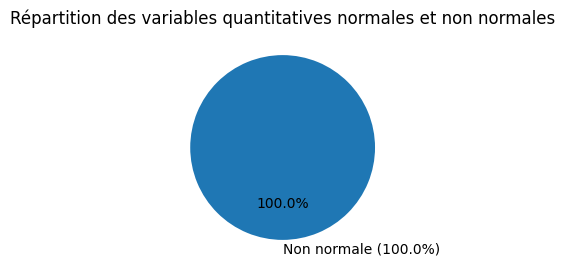

In [70]:

distribution_counts = shapiro_summary["Conclusion"].value_counts()
distribution_percentages = (distribution_counts / distribution_counts.sum() * 100).round(2)

plt.figure(figsize=(3, 3))
plt.pie(
    distribution_counts,
    labels=[f"{label} ({distribution_percentages[label]}%)" for label in distribution_counts.index],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Répartition des variables quantitatives normales et non normales")
plt.show()

In [33]:
df[['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']].head()


,RegistrationDate,NewsletterSubscribed,LastLoginIP,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country
0,17/07/10,Yes,59.252.219.201,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom
1,2010-10-04,Yes,77.255.247.14,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom
2,12/09/2009,Yes,51.139.78.80,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France
3,28/01/10,Yes,10.212.80.124,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom
4,2009-12-10,Yes,186.34.121.80,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom
